In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

print("Starting Data Exploration...")

Starting Data Exploration...


# 1. Data Loading

In [3]:
from pathlib import Path

data_path = Path("../data/raw/dataset.csv")
df = pd.read_csv(data_path)

print(f"Data loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
print(df.head())

Data loaded successfully with 400 rows and 39 columns.
   JOGO RESULTADO  CORINTHIANS GOL COR  GOL VIS      VISITANTE  \
0     1         D  CORINTHIANS       0        1    FIGUEIRENSE   
1     2         E  CORINTHIANS       1        1       BOTAFOGO   
2     3         V  CORINTHIANS       2        1  INTERNACIONAL   
3     4         V  CORINTHIANS       3        0          BAHIA   
4     5         V  CORINTHIANS       2        0      PALMEIRAS   

  CIDADE - VISITANTE  UF PAIS  DIA  ...  GOL-NORTE  GOL VIS-SUL GOL VIS-NORTE  \
0      FLORIANÓPOLIS  SC  BRA   18  ...          0            0             1   
1     RIO DE JANEIRO  RJ  BRA    1  ...          1            0             1   
2       PORTO ALEGRE  RS  BRA   17  ...          0            1             0   
3           SALVADOR  BA  BRA   23  ...          1            0             0   
4          SÃO PAULO  SP  BRA   27  ...          2            0             0   

  GOL-1T GOL-2T GOL VIS-1T GOL VIS-2T                    ÁRBI

In [15]:
print("\nDataset Info:")
print(df.info())

print("\n\nDescriptive Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   JOGO                     400 non-null    int64  
 1   RESULTADO                400 non-null    object 
 2   CORINTHIANS              400 non-null    object 
 3   GOL COR                  400 non-null    object 
 4   GOL VIS                  400 non-null    int64  
 5   VISITANTE                400 non-null    object 
 6   CIDADE - VISITANTE       400 non-null    object 
 7   UF                       400 non-null    object 
 8   PAIS                     400 non-null    object 
 9   DIA                      400 non-null    int64  
 10  MES                      400 non-null    int64  
 11  ANO                      400 non-null    int64  
 12  HORA                     400 non-null    object 
 13  DIA-SEMANA               400 non-null    object 
 14  CAMPEONATO 

# 2. Missing Values

In [30]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
SAÍDA DE JOGO    3
dtype: int64

⚠️ Found 3 missing values


In [31]:
empty_values_by_column = df.apply(lambda col: col.astype(str).str.strip() == "").sum()
print(f"Empty values by column: {empty_values_by_column}")

Empty values by column: JOGO                       0
RESULTADO                  0
CORINTHIANS                0
GOL COR                    0
GOL VIS                    0
VISITANTE                  0
CIDADE - VISITANTE         0
UF                         0
PAIS                       0
DIA                        0
MES                        0
ANO                        0
HORA                       0
DIA-SEMANA                 0
CAMPEONATO                 0
CAPITÃO                    0
TÉCNICO                    0
TÉCNICO - VISITANTE        0
PUBLICO PAGANTE            0
RENDA                      0
CAMISA                     0
SAÍDA DE JOGO              0
1 TEMPO                    0
2 TEMPO                    0
ARTILHEIROS                0
ARTILHEIROS - VISITANTE    0
NUM-GOLS                   0
PRIMEIRO GOL               0
GOL-SUL                    0
GOL-NORTE                  0
GOL VIS-SUL                0
GOL VIS-NORTE              0
GOL-1T                     0
GOL-2T             

# 3. Duplicated Values

In [20]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0

✅ No duplicate rows found


# 4. View Correlations

In [33]:
df_numeric = df.apply(pd.to_numeric, errors='coerce')
corr_matrix = df_numeric.corr()

print(corr_matrix)

                             JOGO  RESULTADO  CORINTHIANS   GOL COR   GOL VIS  \
JOGO                     1.000000        NaN          NaN -0.060795  0.117400   
RESULTADO                     NaN        NaN          NaN       NaN       NaN   
CORINTHIANS                   NaN        NaN          NaN       NaN       NaN   
GOL COR                 -0.060795        NaN          NaN  1.000000  0.018781   
GOL VIS                  0.117400        NaN          NaN  0.018781  1.000000   
VISITANTE                     NaN        NaN          NaN       NaN       NaN   
CIDADE - VISITANTE            NaN        NaN          NaN       NaN       NaN   
UF                            NaN        NaN          NaN       NaN       NaN   
PAIS                          NaN        NaN          NaN       NaN       NaN   
DIA                     -0.005089        NaN          NaN -0.040573 -0.046729   
MES                      0.058749        NaN          NaN -0.078160  0.099736   
ANO                      0.9

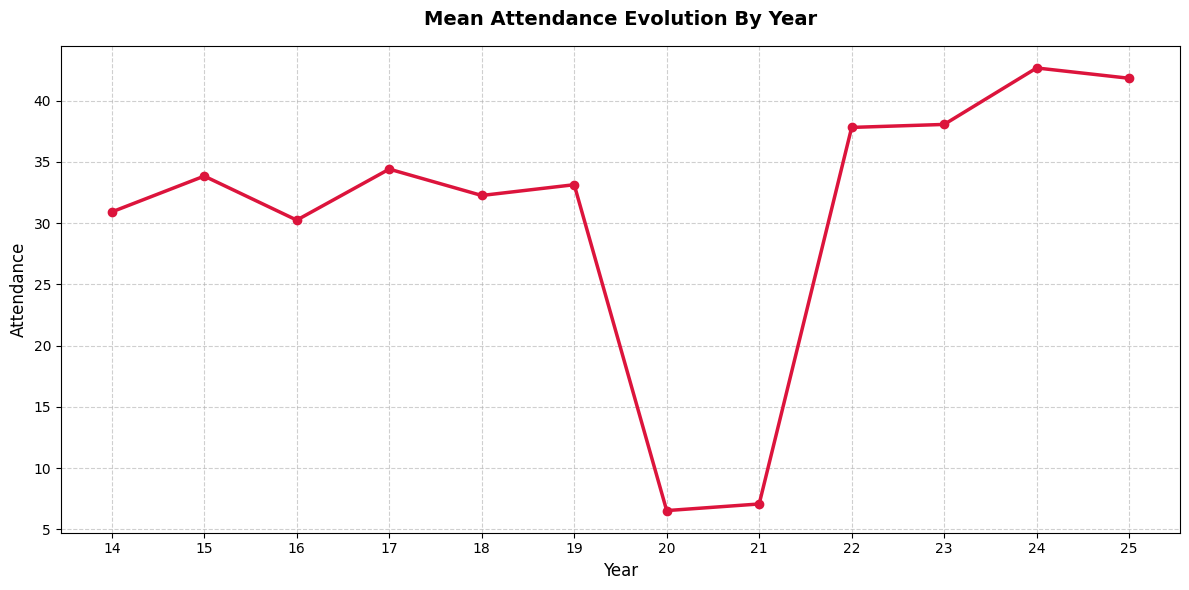

In [5]:
df_by_year = df.groupby('ANO')['PUBLICO PAGANTE'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_by_year['ANO'], df_by_year['PUBLICO PAGANTE'], marker='o', color='crimson', linewidth=2.5, markersize=6)

plt.title('Mean Attendance Evolution By Year', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Attendance', fontsize=12)

plt.xticks(df_by_year['ANO'])

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()